# EDA 8.2: Traffic Source Quality Analysis

This notebook analyzes web traffic source quality, including bounce rate, session duration, traffic share, source mix trends, and observed relationships with Revenue. Results are exploratory and descriptive, not causal claims.

## 1. Setup and File Discovery

Locate `web_traffic.csv` and `sales.csv` anywhere under the current working directory. Missing files produce warnings and the notebook continues where possible.

In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('default')
pd.set_option('display.max_columns', 160)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

ROOT = Path.cwd()
FILES = ['web_traffic.csv', 'sales.csv']

def normalize_name(name):
    return re.sub(r'[^a-z0-9]+', '', str(name).strip().lower())

def safe_col_label(text):
    label = re.sub(r'[^a-z0-9]+', '_', str(text).strip().lower()).strip('_')
    return label or 'unknown'

def discover_csvs(root):
    found = {}
    for path in root.rglob('*.csv'):
        key = path.name.lower()
        if key not in found:
            found[key] = path
    return found

csv_files = discover_csvs(ROOT)
selected_paths = {name: csv_files.get(name.lower()) for name in FILES}
file_status = pd.DataFrame([
    {'file': name, 'found': path is not None, 'path': str(path) if path else None}
    for name, path in selected_paths.items()
])
display(file_status)

for name, path in selected_paths.items():
    if path is None:
        warnings.warn(f'{name} was not found. The notebook will continue where possible.')

,file,found,path
0,web_traffic.csv,True,D:\Code\Datathon 2026\datathon-2026-round-1\we...
1,sales.csv,True,D:\Code\Datathon 2026\datathon-2026-round-1\sa...


## 2. Load Web Traffic and Sales Data

Load each available CSV safely with pandas and display the raw schemas.

In [2]:
def safe_read_csv(path, name):
    if path is None:
        return None
    try:
        df = pd.read_csv(path, low_memory=False)
        print(f'Loaded {name}: {df.shape[0]:,} rows x {df.shape[1]:,} columns from {path}')
        return df
    except Exception as exc:
        warnings.warn(f'Could not load {name} from {path}: {exc}')
        return None

traffic_raw = safe_read_csv(selected_paths.get('web_traffic.csv'), 'web_traffic.csv')
sales_raw = safe_read_csv(selected_paths.get('sales.csv'), 'sales.csv')

schema_rows = []
for name, df in [('web_traffic.csv', traffic_raw), ('sales.csv', sales_raw)]:
    if df is not None:
        schema_rows.append({'file': name, 'rows': len(df), 'columns': len(df.columns), 'column_names': ', '.join(map(str, df.columns))})
schema_overview = pd.DataFrame(schema_rows)
display(schema_overview)

Loaded web_traffic.csv: 3,652 rows x 7 columns from D:\Code\Datathon 2026\datathon-2026-round-1\web_traffic.csv
Loaded sales.csv: 3,833 rows x 3 columns from D:\Code\Datathon 2026\datathon-2026-round-1\sales.csv


,file,rows,columns,column_names
0,web_traffic.csv,3652,7,"date, sessions, unique_visitors, page_views, b..."
1,sales.csv,3833,3,"Date, Revenue, COGS"


## 3. Identify Traffic Source, Quality, Date, and Revenue Columns

Column matching normalizes case, spaces, punctuation, and underscores, then uses candidate names and keyword scoring for minor naming differences.

In [3]:
def column_lookup(df):
    if df is None:
        return {}
    return {normalize_name(c): c for c in df.columns}

def find_col(df, candidates=None, include_all=None, include_any=None, exclude_any=None, prefer_numeric=False):
    if df is None:
        return None
    candidates = candidates or []
    include_all = [normalize_name(x) for x in (include_all or [])]
    include_any = [normalize_name(x) for x in (include_any or [])]
    exclude_any = [normalize_name(x) for x in (exclude_any or [])]
    lookup = column_lookup(df)
    for cand in candidates:
        key = normalize_name(cand)
        if key in lookup:
            return lookup[key]
    scored = []
    for col in df.columns:
        key = normalize_name(col)
        if exclude_any and any(x in key for x in exclude_any):
            continue
        if include_all and not all(x in key for x in include_all):
            continue
        if include_any and not any(x in key for x in include_any):
            continue
        score = sum(3 for x in include_all if x in key) + sum(2 for x in include_any if x in key)
        if prefer_numeric and pd.api.types.is_numeric_dtype(df[col]):
            score += 1
        scored.append((score, len(key), col))
    if scored:
        scored.sort(key=lambda x: (-x[0], x[1], str(x[2])))
        return scored[0][2]
    return None

def to_num(s):
    return pd.to_numeric(s, errors='coerce')

def infer_revenue_col(df):
    if df is None:
        return None
    direct = find_col(
        df,
        ['revenue', 'total_revenue', 'sales_amount', 'sales', 'net_sales', 'amount'],
        include_any=['revenue', 'salesamount', 'totalsales', 'netsales'],
        exclude_any=['cost', 'cogs', 'margin', 'profit', 'tax'],
        prefer_numeric=True,
    )
    if direct is not None:
        return direct
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) or to_num(df[c]).notna().mean() > 0.8]
    candidates = []
    for c in numeric_cols:
        key = normalize_name(c)
        if any(x in key for x in ['cost', 'cogs', 'margin', 'profit', 'tax', 'id']):
            continue
        vals = to_num(df[c])
        candidates.append(((vals > 0).mean(), vals.abs().sum(skipna=True), c))
    if candidates:
        candidates.sort(key=lambda x: (-x[0], -x[1], str(x[2])))
        warnings.warn(f'Revenue column was not explicit; using likely numeric revenue column: {candidates[0][2]}')
        return candidates[0][2]
    return None

cols = {}
if traffic_raw is not None:
    cols['traffic_date'] = find_col(traffic_raw, ['date', 'traffic_date', 'visit_date', 'event_date', 'session_date'], include_any=['date', 'day'])
    cols['traffic_source'] = find_col(traffic_raw, ['traffic_source', 'source', 'channel', 'medium', 'traffic_channel'], include_any=['trafficsource', 'source', 'channel', 'medium'])
    cols['sessions'] = find_col(traffic_raw, ['sessions', 'session_count', 'visits'], include_any=['sessions', 'sessioncount', 'visits'], prefer_numeric=True)
    cols['page_views'] = find_col(traffic_raw, ['page_views', 'pageviews', 'views', 'page_view_count'], include_any=['pageviews', 'pageviewcount', 'views'], prefer_numeric=True)
    cols['unique_visitors'] = find_col(traffic_raw, ['unique_visitors', 'unique_users', 'users', 'visitors'], include_any=['uniquevisitors', 'uniqueusers', 'users', 'visitors'], exclude_any=['sessions'], prefer_numeric=True)
    cols['bounce_rate'] = find_col(traffic_raw, ['bounce_rate', 'bouncerate', 'bounce_pct', 'bounce_percentage'], include_any=['bouncerate', 'bouncepct', 'bouncepercentage'], prefer_numeric=True)
    cols['session_duration'] = find_col(traffic_raw, ['avg_session_duration_sec', 'avg_session_duration', 'average_session_duration', 'session_duration', 'duration'], include_any=['sessionduration', 'averagesessionduration', 'avgsessionduration', 'duration'], prefer_numeric=True)
if sales_raw is not None:
    cols['sales_date'] = find_col(sales_raw, ['date', 'sales_date', 'order_date', 'revenue_date'], include_any=['date', 'day'])
    cols['revenue'] = infer_revenue_col(sales_raw)

identified_columns = pd.DataFrame([{'role': k, 'column': v} for k, v in cols.items()])
display(identified_columns)

,role,column
0,traffic_date,date
1,traffic_source,traffic_source
2,sessions,sessions
3,page_views,page_views
4,unique_visitors,unique_visitors
5,bounce_rate,bounce_rate
6,session_duration,avg_session_duration_sec
7,sales_date,Date
8,revenue,Revenue


## 4. Prepare Traffic Source Dataset

Standardize source labels, aggregate to daily source level, and report coverage, missing values, duplicate date-source rows, and invalid traffic values.

In [4]:
traffic_source_daily = pd.DataFrame()
traffic_warnings = []

def standardize_source(value):
    if pd.isna(value) or str(value).strip() == '':
        return 'unknown'
    s = str(value).strip().lower()
    s = re.sub(r'[\s\-]+', '_', s)
    if 'organic' in s:
        return 'organic'
    if 'paid' in s or 'ppc' in s or 'cpc' in s or 'sem' in s:
        return 'paid'
    if 'email' in s or 'newsletter' in s:
        return 'email'
    if 'social' in s or s in {'facebook', 'instagram', 'twitter', 'x', 'tiktok', 'linkedin'}:
        return 'social'
    if 'direct' in s:
        return 'direct'
    if 'referral' in s or 'affiliate' in s:
        return 'referral'
    if 'display' in s or 'banner' in s:
        return 'display'
    return s

def weighted_avg(values, weights):
    v = pd.Series(pd.to_numeric(values, errors='coerce'))
    w = pd.Series(pd.to_numeric(weights, errors='coerce')).fillna(0)
    if len(w) != len(v):
        w = pd.Series(np.ones(len(v)))
    valid = v.notna() & w.notna() & (w > 0)
    if valid.any():
        return np.average(v[valid], weights=w[valid])
    return v.mean(skipna=True)

if traffic_raw is None or traffic_raw.empty:
    traffic_warnings.append('web_traffic.csv is missing or empty.')
elif cols.get('traffic_date') is None:
    traffic_warnings.append('Traffic date column could not be identified.')
elif cols.get('traffic_source') is None:
    traffic_warnings.append('Traffic source/channel/medium column could not be identified.')
else:
    tr = traffic_raw.copy()
    tr['date'] = pd.to_datetime(tr[cols['traffic_date']], errors='coerce').dt.floor('D')
    tr['traffic_source_raw'] = tr[cols['traffic_source']]
    tr['traffic_source'] = tr[cols['traffic_source']].map(standardize_source)
    for role in ['sessions', 'page_views', 'unique_visitors', 'bounce_rate', 'session_duration']:
        if cols.get(role):
            tr[role] = to_num(tr[cols[role]])

    duplicate_date_source_rows = int(tr.duplicated(['date', 'traffic_source']).sum())
    missing_source_values = int(tr[cols['traffic_source']].isna().sum() + (tr[cols['traffic_source']].astype('string').str.strip() == '').sum())
    agg_rows = []
    for (date, source), g in tr.dropna(subset=['date']).groupby(['date', 'traffic_source'], dropna=False):
        row = {'date': date, 'traffic_source': source}
        if 'sessions' in g:
            row['sessions'] = g['sessions'].sum(min_count=1)
        if 'page_views' in g:
            row['page_views'] = g['page_views'].sum(min_count=1)
        if 'unique_visitors' in g:
            row['unique_visitors'] = g['unique_visitors'].sum(min_count=1)
        weights = g['sessions'] if 'sessions' in g else pd.Series(1, index=g.index)
        if 'bounce_rate' in g:
            br = g['bounce_rate'].copy()
            row['bounce_rate'] = weighted_avg(np.where(br.abs() > 1.5, br / 100.0, br), weights)
        if 'session_duration' in g:
            row['session_duration'] = weighted_avg(g['session_duration'], weights)
        agg_rows.append(row)
    traffic_source_daily = pd.DataFrame(agg_rows).sort_values(['date', 'traffic_source'])

    report = pd.DataFrame([
        {'metric': 'traffic_date_range_start', 'value': traffic_source_daily['date'].min()},
        {'metric': 'traffic_date_range_end', 'value': traffic_source_daily['date'].max()},
        {'metric': 'number_of_traffic_sources', 'value': traffic_source_daily['traffic_source'].nunique()},
        {'metric': 'total_sessions', 'value': traffic_source_daily['sessions'].sum() if 'sessions' in traffic_source_daily else np.nan},
        {'metric': 'missing_traffic_source_values_raw', 'value': missing_source_values},
        {'metric': 'missing_bounce_rate_values_raw', 'value': int(tr['bounce_rate'].isna().sum()) if 'bounce_rate' in tr else np.nan},
        {'metric': 'missing_session_duration_values_raw', 'value': int(tr['session_duration'].isna().sum()) if 'session_duration' in tr else np.nan},
        {'metric': 'duplicate_date_source_rows_raw', 'value': duplicate_date_source_rows},
        {'metric': 'zero_or_negative_sessions_rows_daily_source', 'value': int((traffic_source_daily['sessions'].fillna(0) <= 0).sum()) if 'sessions' in traffic_source_daily else np.nan},
    ])
    display(report)
    display(traffic_source_daily.head())
    numeric_cols = [c for c in ['sessions', 'page_views', 'unique_visitors', 'bounce_rate', 'session_duration'] if c in traffic_source_daily.columns]
    if numeric_cols:
        display(traffic_source_daily[numeric_cols].describe().T)

if traffic_warnings:
    print('Traffic warnings:')
    for w in traffic_warnings:
        print('-', w)

,metric,value
0,traffic_date_range_start,2013-01-01 00:00:00
1,traffic_date_range_end,2022-12-31 00:00:00
2,number_of_traffic_sources,6
3,total_sessions,91452537
4,missing_traffic_source_values_raw,0
5,missing_bounce_rate_values_raw,0
6,missing_session_duration_values_raw,0
7,duplicate_date_source_rows_raw,0
8,zero_or_negative_sessions_rows_daily_source,0


,date,traffic_source,sessions,page_views,unique_visitors,bounce_rate,session_duration
0,2013-01-01,organic,9760,39093,7253,0.0051,102.9000
1,2013-01-02,organic,10456,47611,8151,0.0041,120.5000
2,2013-01-03,direct,10076,36963,7458,0.0040,263.6000
3,2013-01-04,direct,9973,53078,8063,0.0056,151.8000
4,2013-01-05,referral,10223,36790,7882,0.0053,168.6000


,count,mean,std,min,25%,50%,75%,max
sessions,"3,652.0000","25,041.7681","9,422.6093","7,973.0000","17,099.2500","23,633.5000","31,782.7500","50,947.0000"
page_views,"3,652.0000","108,615.2245","44,472.0555","30,451.0000","72,982.0000","101,010.5000","138,086.0000","275,560.0000"
unique_visitors,"3,652.0000","19,031.4044","7,237.9531","6,136.0000","12,915.0000","17,924.0000","24,191.7500","40,430.0000"
bounce_rate,"3,652.0000",0.0045,0.0008,0.0032,0.0038,0.0044,0.0052,0.0058
session_duration,"3,652.0000",210.2832,63.7717,100.1000,156.7000,209.2000,266.2000,319.9000


## 5. Prepare Daily Revenue Dataset

Aggregate sales to daily Revenue and report date range, invalid values, and later overlap with traffic.

In [5]:
sales_daily = pd.DataFrame()
sales_warnings = []

if sales_raw is None or sales_raw.empty:
    sales_warnings.append('sales.csv is missing or empty.')
elif cols.get('sales_date') is None:
    sales_warnings.append('Sales date column could not be identified.')
elif cols.get('revenue') is None:
    sales_warnings.append('Revenue column could not be identified or inferred.')
else:
    sa = sales_raw.copy()
    sa['date'] = pd.to_datetime(sa[cols['sales_date']], errors='coerce').dt.floor('D')
    sa['revenue'] = to_num(sa[cols['revenue']])
    duplicate_sales_dates = int(sa['date'].duplicated().sum())
    sales_daily = sa.dropna(subset=['date']).groupby('date', as_index=False)['revenue'].sum(min_count=1)
    sales_report = pd.DataFrame([
        {'metric': 'sales_date_range_start', 'value': sales_daily['date'].min()},
        {'metric': 'sales_date_range_end', 'value': sales_daily['date'].max()},
        {'metric': 'sales_days', 'value': len(sales_daily)},
        {'metric': 'raw_duplicate_sales_dates', 'value': duplicate_sales_dates},
        {'metric': 'zero_revenue_days', 'value': int((sales_daily['revenue'].fillna(0) == 0).sum())},
        {'metric': 'negative_revenue_days', 'value': int((sales_daily['revenue'].fillna(0) < 0).sum())},
    ])
    display(sales_report)
    display(sales_daily[['revenue']].describe().T)
    display(sales_daily.head())

if sales_warnings:
    print('Sales warnings:')
    for w in sales_warnings:
        print('-', w)

,metric,value
0,sales_date_range_start,2012-07-04 00:00:00
1,sales_date_range_end,2022-12-31 00:00:00
2,sales_days,3833
3,raw_duplicate_sales_dates,0
4,zero_revenue_days,0
5,negative_revenue_days,0


,count,mean,std,min,25%,50%,75%,max
revenue,"3,833.0000","4,286,584.0296","2,624,840.1982","279,813.9400","2,471,088.8200","3,647,303.9000","5,350,877.2000","20,905,271.3500"


,date,revenue
0,2012-07-04,"5,123,547.9400"
1,2012-07-05,"2,751,773.4500"
2,2012-07-06,"3,054,029.4200"
3,2012-07-07,"2,667,930.9400"
4,2012-07-08,"2,360,851.9000"


## 6. Traffic Source Volume and Share

Compute total sessions, session share, page views, unique visitors, active days, and average daily sessions by source. Sparse sources are flagged for cautious interpretation.

,traffic_source,total_sessions,active_days,average_daily_sessions,total_page_views,total_unique_visitors,sessions_share,sparse_source_flag
2,organic,27196976,1090,"24,951.3541",117606452,20625107,0.2974,False
3,paid,19598271,784,"24,997.7946",85079551,14922386,0.2143,False
5,social,15816226,632,"25,025.6741",68072140,12048065,0.1729,False
1,email,12792670,505,"25,332.0198",55477636,9700462,0.1399,False
4,referral,9476845,375,"25,271.5867",41655659,7220019,0.1036,False
0,direct,6571549,266,"24,705.0714",28771362,4986650,0.0719,False


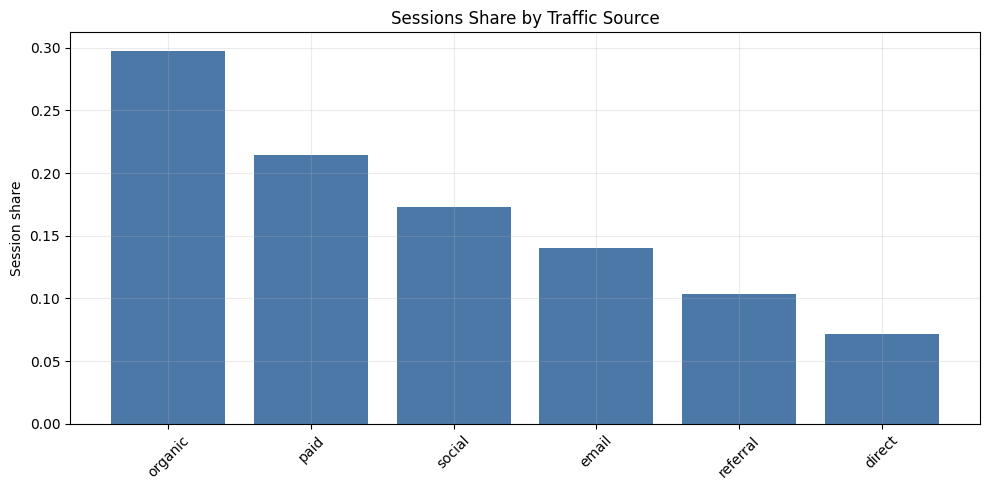

Dominant traffic sources:


,traffic_source,total_sessions,active_days,average_daily_sessions,total_page_views,total_unique_visitors,sessions_share,sparse_source_flag
2,organic,27196976,1090,"24,951.3541",117606452,20625107,0.2974,False
3,paid,19598271,784,"24,997.7946",85079551,14922386,0.2143,False
5,social,15816226,632,"25,025.6741",68072140,12048065,0.1729,False
1,email,12792670,505,"25,332.0198",55477636,9700462,0.1399,False
4,referral,9476845,375,"25,271.5867",41655659,7220019,0.1036,False


Minor or sparse traffic sources:


,traffic_source,total_sessions,active_days,average_daily_sessions,total_page_views,total_unique_visitors,sessions_share,sparse_source_flag


In [6]:
source_volume = pd.DataFrame()
if traffic_source_daily.empty or 'sessions' not in traffic_source_daily.columns:
    print('Traffic source sessions are unavailable; volume/share analysis cannot be computed.')
else:
    agg_map = {
        'total_sessions': ('sessions', 'sum'),
        'active_days': ('date', 'nunique'),
        'average_daily_sessions': ('sessions', 'mean'),
    }
    if 'page_views' in traffic_source_daily.columns:
        agg_map['total_page_views'] = ('page_views', 'sum')
    if 'unique_visitors' in traffic_source_daily.columns:
        agg_map['total_unique_visitors'] = ('unique_visitors', 'sum')
    source_volume = traffic_source_daily.groupby('traffic_source').agg(**agg_map).reset_index()
    total_sessions = source_volume['total_sessions'].sum()
    source_volume['sessions_share'] = source_volume['total_sessions'] / total_sessions if total_sessions else np.nan
    source_volume['sparse_source_flag'] = source_volume['sessions_share'] < 0.01
    source_volume = source_volume.sort_values('total_sessions', ascending=False)
    display(source_volume)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(source_volume['traffic_source'], source_volume['sessions_share'], color='#4C78A8')
    ax.set_title('Sessions Share by Traffic Source')
    ax.set_ylabel('Session share')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    print('Dominant traffic sources:')
    display(source_volume.head(5))
    print('Minor or sparse traffic sources:')
    display(source_volume[source_volume['sparse_source_flag']].head(20))

## 7. Traffic Source Quality

Compare bounce rate, session duration, page views per session, and sessions per visitor by source. Metrics are weighted by sessions where appropriate.

,traffic_source,total_sessions,active_days,average_bounce_rate,median_bounce_rate,average_session_duration,median_session_duration,page_views_per_session,sessions_per_visitor,sessions_share,sparse_source_flag
1,email,12792670,505,0.0044,0.0044,212.4599,210.8000,4.3367,1.3188,0.1399,False
5,social,15816226,632,0.0045,0.0045,210.9789,209.9500,4.3039,1.3128,0.1729,False
3,paid,19598271,784,0.0045,0.0044,208.2681,209.3000,4.3412,1.3133,0.2143,False
2,organic,27196976,1090,0.0045,0.0045,211.0811,209.0500,4.3242,1.3186,0.2974,False
0,direct,6571549,266,0.0045,0.0044,206.0632,203.6000,4.3782,1.3178,0.0719,False
4,referral,9476845,375,0.0045,0.0045,205.8840,209.4000,4.3955,1.3126,0.1036,False


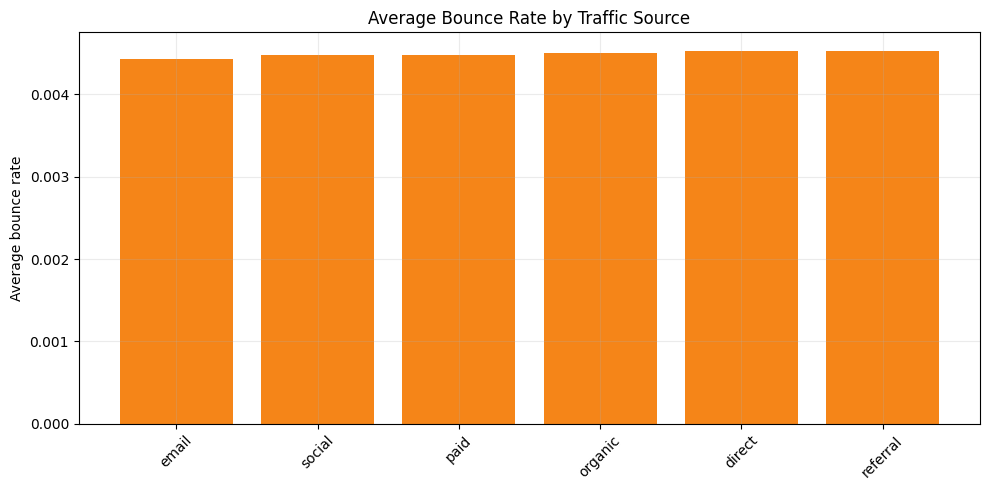

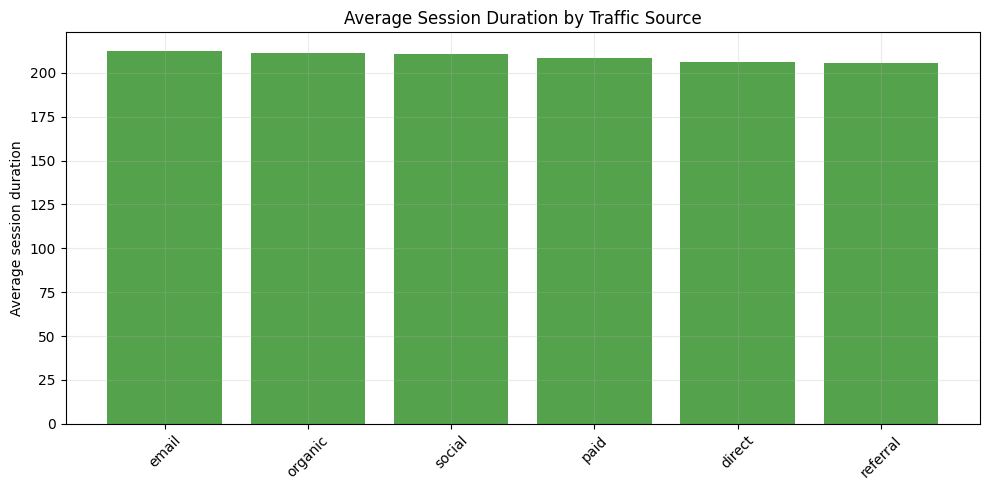

Lowest bounce-rate sources:


,traffic_source,total_sessions,active_days,average_bounce_rate,median_bounce_rate,average_session_duration,median_session_duration,page_views_per_session,sessions_per_visitor,sessions_share,sparse_source_flag
1,email,12792670,505,0.0044,0.0044,212.4599,210.8000,4.3367,1.3188,0.1399,False
5,social,15816226,632,0.0045,0.0045,210.9789,209.9500,4.3039,1.3128,0.1729,False
3,paid,19598271,784,0.0045,0.0044,208.2681,209.3000,4.3412,1.3133,0.2143,False
2,organic,27196976,1090,0.0045,0.0045,211.0811,209.0500,4.3242,1.3186,0.2974,False
0,direct,6571549,266,0.0045,0.0044,206.0632,203.6000,4.3782,1.3178,0.0719,False


Highest session-duration sources:


,traffic_source,total_sessions,active_days,average_bounce_rate,median_bounce_rate,average_session_duration,median_session_duration,page_views_per_session,sessions_per_visitor,sessions_share,sparse_source_flag
1,email,12792670,505,0.0044,0.0044,212.4599,210.8000,4.3367,1.3188,0.1399,False
2,organic,27196976,1090,0.0045,0.0045,211.0811,209.0500,4.3242,1.3186,0.2974,False
5,social,15816226,632,0.0045,0.0045,210.9789,209.9500,4.3039,1.3128,0.1729,False
3,paid,19598271,784,0.0045,0.0044,208.2681,209.3000,4.3412,1.3133,0.2143,False
0,direct,6571549,266,0.0045,0.0044,206.0632,203.6000,4.3782,1.3178,0.0719,False


High volume but weaker bounce-rate quality candidates:


,traffic_source,total_sessions,active_days,average_bounce_rate,median_bounce_rate,average_session_duration,median_session_duration,page_views_per_session,sessions_per_visitor,sessions_share,sparse_source_flag


Low volume but stronger bounce-rate quality candidates:


,traffic_source,total_sessions,active_days,average_bounce_rate,median_bounce_rate,average_session_duration,median_session_duration,page_views_per_session,sessions_per_visitor,sessions_share,sparse_source_flag


In [7]:
source_quality = pd.DataFrame()
if traffic_source_daily.empty:
    print('Traffic source data is unavailable; quality analysis cannot be computed.')
else:
    rows = []
    for source, g in traffic_source_daily.groupby('traffic_source'):
        row = {
            'traffic_source': source,
            'total_sessions': g['sessions'].sum() if 'sessions' in g else np.nan,
            'active_days': g['date'].nunique(),
        }
        weights = g['sessions'] if 'sessions' in g else pd.Series(1, index=g.index)
        if 'bounce_rate' in g:
            row['average_bounce_rate'] = weighted_avg(g['bounce_rate'], weights)
            row['median_bounce_rate'] = g['bounce_rate'].median()
        if 'session_duration' in g:
            row['average_session_duration'] = weighted_avg(g['session_duration'], weights)
            row['median_session_duration'] = g['session_duration'].median()
        if {'page_views', 'sessions'}.issubset(g.columns):
            row['page_views_per_session'] = g['page_views'].sum() / g['sessions'].sum() if g['sessions'].sum() else np.nan
        if {'sessions', 'unique_visitors'}.issubset(g.columns):
            row['sessions_per_visitor'] = g['sessions'].sum() / g['unique_visitors'].sum() if g['unique_visitors'].sum() else np.nan
        rows.append(row)
    source_quality = pd.DataFrame(rows)
    if not source_volume.empty:
        source_quality = source_quality.merge(source_volume[['traffic_source', 'sessions_share', 'sparse_source_flag']], on='traffic_source', how='left')
    sort_col = 'average_bounce_rate' if 'average_bounce_rate' in source_quality.columns else 'total_sessions'
    display(source_quality.sort_values(sort_col))

    if 'average_bounce_rate' in source_quality.columns:
        plot_data = source_quality.sort_values('average_bounce_rate')
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(plot_data['traffic_source'], plot_data['average_bounce_rate'], color='#F58518')
        ax.set_title('Average Bounce Rate by Traffic Source')
        ax.set_ylabel('Average bounce rate')
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print('Bounce rate is unavailable; bounce-rate chart skipped.')

    if 'average_session_duration' in source_quality.columns:
        plot_data = source_quality.sort_values('average_session_duration', ascending=False)
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(plot_data['traffic_source'], plot_data['average_session_duration'], color='#54A24B')
        ax.set_title('Average Session Duration by Traffic Source')
        ax.set_ylabel('Average session duration')
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print('Session duration is unavailable; session-duration chart skipped.')

    if 'average_bounce_rate' in source_quality.columns:
        print('Lowest bounce-rate sources:')
        display(source_quality.sort_values('average_bounce_rate').head(5))
    if 'average_session_duration' in source_quality.columns:
        print('Highest session-duration sources:')
        display(source_quality.sort_values('average_session_duration', ascending=False).head(5))
    if {'sessions_share', 'average_bounce_rate'}.issubset(source_quality.columns):
        weak_quality = source_quality[(source_quality['sessions_share'] >= source_quality['sessions_share'].quantile(0.75)) & (source_quality['average_bounce_rate'] >= source_quality['average_bounce_rate'].quantile(0.75))]
        strong_quality_low_volume = source_quality[(source_quality['sessions_share'] <= source_quality['sessions_share'].quantile(0.25)) & (source_quality['average_bounce_rate'] <= source_quality['average_bounce_rate'].quantile(0.25))]
        print('High volume but weaker bounce-rate quality candidates:')
        display(weak_quality)
        print('Low volume but stronger bounce-rate quality candidates:')
        display(strong_quality_low_volume)

## 8. Traffic Source Trends Over Time

Plot sessions over time for top sources and display monthly source mix. Growth/decline is estimated using first-vs-last 30 active daily values per source.

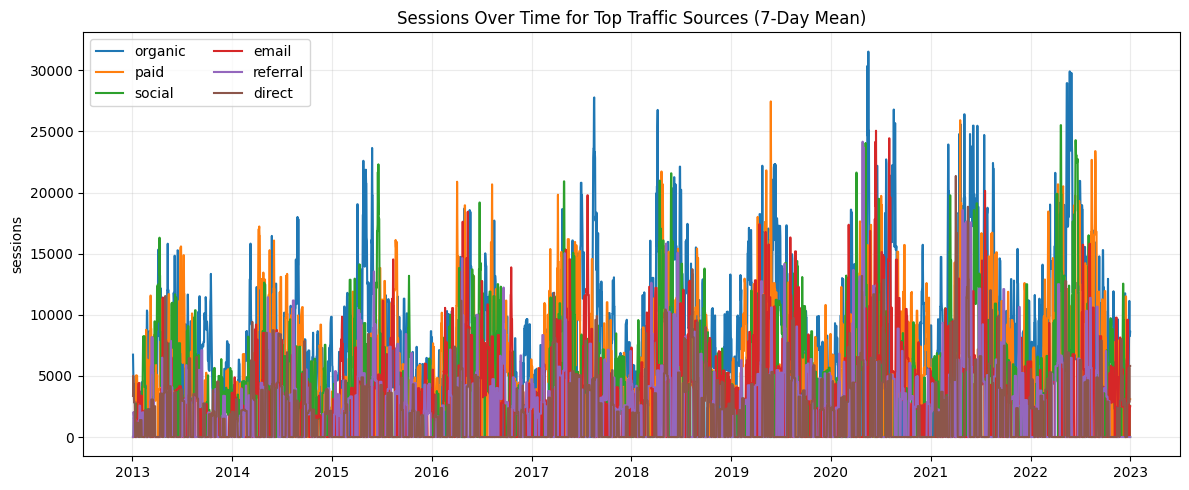

,traffic_source,trend_direction,first_30_day_avg_sessions,last_30_day_avg_sessions,pct_change
2,organic,increasing,"2,604.6000","6,755.6667",1.5937
5,social,increasing,959.2000,"4,236.9667",3.4172
1,email,increasing,"1,654.9667","3,553.4000",1.1471
3,paid,increasing,"2,118.0667","3,405.6667",0.6079
0,direct,increasing,"1,261.7333","2,741.2667",1.1726
4,referral,decreasing,937.8000,0.0000,-1.0000


traffic_source,direct,email,organic,paid,referral,social
month,,,,,,
2021-01-01,0.0934,0.0669,0.2045,0.2517,0.1593,0.2242
2021-02-01,0.1069,0.1123,0.3279,0.0941,0.1340,0.2247
2021-03-01,0.1592,0.1272,0.2891,0.1592,0.0660,0.1993
2021-04-01,0.0645,0.1291,0.3665,0.2099,0.1308,0.0993
2021-05-01,0.1321,0.0921,0.3322,0.0954,0.2222,0.1260
2021-06-01,0.0686,0.0658,0.3338,0.1374,0.0980,0.2965
2021-07-01,0.0000,0.2615,0.4201,0.1248,0.0962,0.0974
2021-08-01,0.1325,0.0966,0.2917,0.3117,0.0669,0.1007
2021-09-01,0.1340,0.1033,0.2911,0.1316,0.1735,0.1665


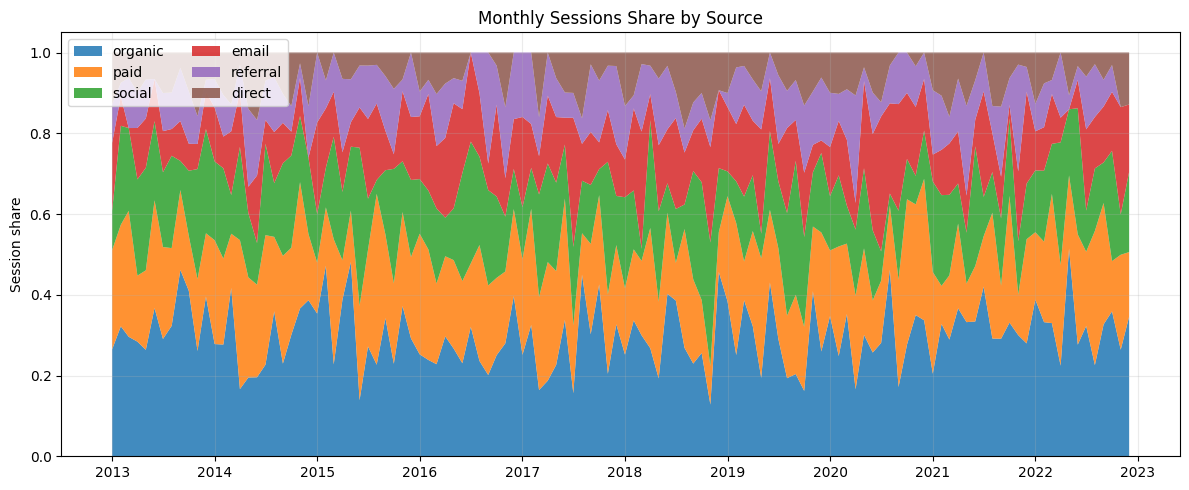

In [8]:
source_trends = pd.DataFrame()
source_sessions_pivot = pd.DataFrame()
if traffic_source_daily.empty or 'sessions' not in traffic_source_daily.columns:
    print('Traffic source sessions are unavailable; source trend analysis cannot be computed.')
else:
    top_sources = source_volume.head(6)['traffic_source'].tolist() if not source_volume.empty else traffic_source_daily['traffic_source'].value_counts().head(6).index.tolist()
    source_sessions_pivot = traffic_source_daily.pivot_table(index='date', columns='traffic_source', values='sessions', aggfunc='sum').fillna(0).sort_index()
    fig, ax = plt.subplots(figsize=(12, 5))
    for source in top_sources:
        if source in source_sessions_pivot.columns:
            ax.plot(source_sessions_pivot.index, source_sessions_pivot[source].rolling(7, min_periods=3).mean(), label=source)
    ax.set_title('Sessions Over Time for Top Traffic Sources (7-Day Mean)')
    ax.set_ylabel('sessions')
    ax.legend(ncol=2)
    plt.tight_layout()
    plt.show()

    trend_rows = []
    for source in source_sessions_pivot.columns:
        s = source_sessions_pivot[source]
        if len(s) >= 60:
            first = s.iloc[:30].mean()
            last = s.iloc[-30:].mean()
            pct_change = (last - first) / first if first else np.nan
            direction = 'stable' if pd.isna(pct_change) or abs(pct_change) < 0.05 else ('increasing' if pct_change > 0 else 'decreasing')
        else:
            first, last, pct_change, direction = np.nan, np.nan, np.nan, 'insufficient data'
        trend_rows.append({'traffic_source': source, 'trend_direction': direction, 'first_30_day_avg_sessions': first, 'last_30_day_avg_sessions': last, 'pct_change': pct_change})
    source_trends = pd.DataFrame(trend_rows).sort_values('last_30_day_avg_sessions', ascending=False)
    display(source_trends)

    monthly = traffic_source_daily.copy()
    monthly['month'] = monthly['date'].dt.to_period('M').dt.to_timestamp()
    monthly_mix = monthly.groupby(['month', 'traffic_source'])['sessions'].sum().reset_index()
    monthly_pivot = monthly_mix.pivot(index='month', columns='traffic_source', values='sessions').fillna(0).sort_index()
    monthly_share = monthly_pivot.div(monthly_pivot.sum(axis=1).replace(0, np.nan), axis=0)
    display(monthly_share.tail(24))

    plot_share = monthly_share[top_sources].copy() if set(top_sources).issubset(monthly_share.columns) else monthly_share
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.stackplot(plot_share.index, [plot_share[c] for c in plot_share.columns], labels=plot_share.columns, alpha=0.85)
    ax.set_title('Monthly Sessions Share by Source')
    ax.set_ylabel('Session share')
    ax.legend(loc='upper left', ncol=2)
    plt.tight_layout()
    plt.show()

## 9. Join Source-Level Traffic with Revenue

Pivot source-level sessions into daily columns and join with daily Revenue. The overlap report shows whether traffic and sales cover the same dates.

In [9]:
joined = pd.DataFrame()
source_col_map = {}
if traffic_source_daily.empty or sales_daily.empty or 'sessions' not in traffic_source_daily.columns:
    print('Traffic source sessions or daily Revenue are unavailable; join analysis cannot be computed.')
else:
    source_sessions = traffic_source_daily.pivot_table(index='date', columns='traffic_source', values='sessions', aggfunc='sum').fillna(0)
    source_col_map = {source: f'sessions_{safe_col_label(source)}' for source in source_sessions.columns}
    source_sessions = source_sessions.rename(columns=source_col_map).reset_index()
    source_sessions['total_sessions'] = source_sessions[[c for c in source_sessions.columns if c.startswith('sessions_')]].sum(axis=1)
    joined = source_sessions.merge(sales_daily, on='date', how='outer', indicator=True).sort_values('date')
    overlap = joined[joined['_merge'] == 'both']
    overlap_report = pd.DataFrame([
        {'metric': 'traffic_only_dates', 'value': int((joined['_merge'] == 'left_only').sum())},
        {'metric': 'sales_only_dates', 'value': int((joined['_merge'] == 'right_only').sum())},
        {'metric': 'overlapping_dates', 'value': len(overlap)},
        {'metric': 'overlap_start_date', 'value': overlap['date'].min() if not overlap.empty else pd.NaT},
        {'metric': 'overlap_end_date', 'value': overlap['date'].max() if not overlap.empty else pd.NaT},
    ])
    display(overlap_report)
    joined = joined.drop(columns=['_merge'])
    display(joined.head())
    display(joined.tail())

,metric,value
0,traffic_only_dates,0
1,sales_only_dates,181
2,overlapping_dates,3652
3,overlap_start_date,2013-01-01 00:00:00
4,overlap_end_date,2022-12-31 00:00:00


,date,sessions_direct,sessions_email,sessions_organic,sessions_paid,sessions_referral,sessions_social,total_sessions,revenue
0,2012-07-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"5,123,547.9400"
1,2012-07-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"2,751,773.4500"
2,2012-07-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"3,054,029.4200"
3,2012-07-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"2,667,930.9400"
4,2012-07-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"2,360,851.9000"


,date,sessions_direct,sessions_email,sessions_organic,sessions_paid,sessions_referral,sessions_social,total_sessions,revenue
3828,2022-12-27,0.0000,0.0000,"17,416.0000",0.0000,0.0000,0.0000,"17,416.0000","2,100,553.6600"
3829,2022-12-28,0.0000,0.0000,"21,071.0000",0.0000,0.0000,0.0000,"21,071.0000","3,448,729.2000"
3830,2022-12-29,"20,884.0000",0.0000,0.0000,0.0000,0.0000,0.0000,"20,884.0000","3,083,944.3300"
3831,2022-12-30,0.0000,"17,679.0000",0.0000,0.0000,0.0000,0.0000,"17,679.0000","2,884,668.7600"
3832,2022-12-31,0.0000,0.0000,"21,743.0000",0.0000,0.0000,0.0000,"21,743.0000","2,383,037.4800"


## 10. Revenue Correlation by Source

Calculate same-day and lagged correlations between daily Revenue and source-level sessions. Correlation does not imply causation.

,traffic_source,feature,feature_type,correlation_with_revenue,valid_days,sessions_share,high_corr_low_volume_flag
23,social,sessions_social_roll_mean_7,roll_mean_7,0.1586,3649,0.1729,False
15,paid,sessions_paid_roll_mean_7,roll_mean_7,0.1527,3649,0.2143,False
11,organic,sessions_organic_roll_mean_7,roll_mean_7,0.1310,3649,0.2974,False
19,referral,sessions_referral_roll_mean_7,roll_mean_7,0.1078,3649,0.1036,False
7,email,sessions_email_roll_mean_7,roll_mean_7,0.1019,3649,0.1399,False
20,social,sessions_social,same_day,0.0806,3652,0.1729,False
21,social,sessions_social_lag_1,lag_1,0.0757,3651,0.1729,False
3,direct,sessions_direct_roll_mean_7,roll_mean_7,0.0756,3649,0.0719,False
13,paid,sessions_paid_lag_1,lag_1,0.0704,3651,0.2143,False
12,paid,sessions_paid,same_day,0.0686,3652,0.2143,False


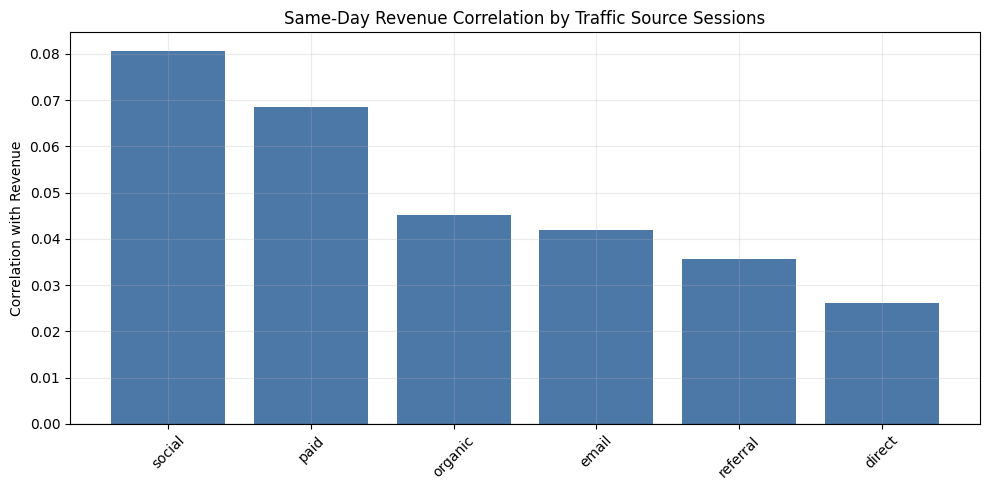

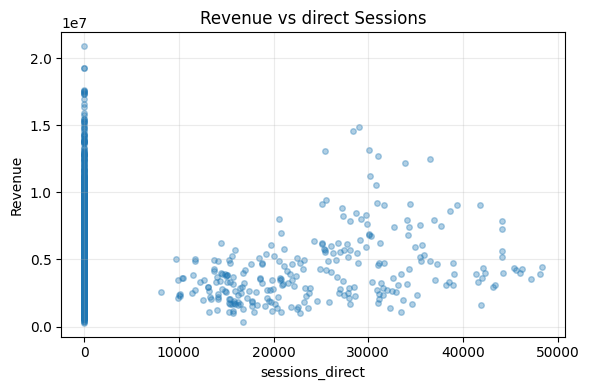

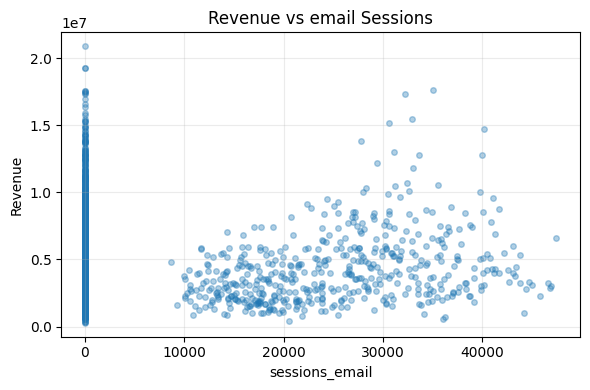

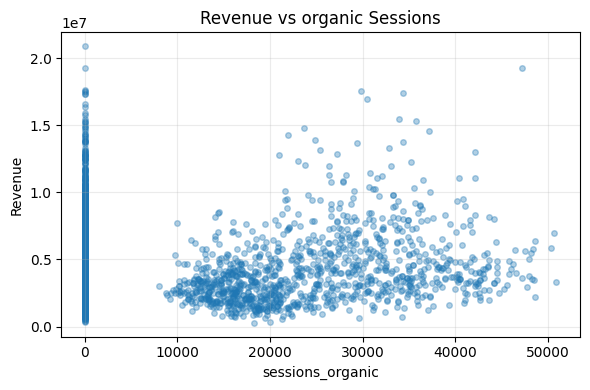

In [10]:
source_correlation = pd.DataFrame()
if joined.empty or 'revenue' not in joined.columns:
    print('Joined source traffic and Revenue data is unavailable; correlation analysis cannot be computed.')
else:
    rel = joined.sort_values('date').copy()
    session_cols = [c for c in rel.columns if c.startswith('sessions_') and c != 'sessions_total']
    corr_rows = []
    for source, col in source_col_map.items():
        if col not in rel.columns:
            continue
        rel[f'{col}_lag_1'] = rel[col].shift(1)
        rel[f'{col}_lag_7'] = rel[col].shift(7)
        rel[f'{col}_roll_mean_7'] = rel[col].shift(1).rolling(7, min_periods=3).mean()
        source_volume_share = source_volume.set_index('traffic_source').loc[source, 'sessions_share'] if not source_volume.empty and source in set(source_volume['traffic_source']) else np.nan
        for feature_type, feature_col in [('same_day', col), ('lag_1', f'{col}_lag_1'), ('lag_7', f'{col}_lag_7'), ('roll_mean_7', f'{col}_roll_mean_7')]:
            valid = rel[['revenue', feature_col]].replace([np.inf, -np.inf], np.nan).dropna()
            corr_rows.append({
                'traffic_source': source,
                'feature': feature_col,
                'feature_type': feature_type,
                'correlation_with_revenue': valid['revenue'].corr(valid[feature_col]) if len(valid) >= 2 else np.nan,
                'valid_days': len(valid),
                'sessions_share': source_volume_share,
                'high_corr_low_volume_flag': False,
            })
    source_correlation = pd.DataFrame(corr_rows)
    if not source_correlation.empty:
        abs_threshold = source_correlation['correlation_with_revenue'].abs().quantile(0.75)
        source_correlation['high_corr_low_volume_flag'] = (source_correlation['correlation_with_revenue'].abs() >= abs_threshold) & (source_correlation['sessions_share'] < 0.05)
        display(source_correlation.sort_values('correlation_with_revenue', ascending=False))
        same_day_corr = source_correlation[source_correlation['feature_type'].eq('same_day')].sort_values('correlation_with_revenue', ascending=False)
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(same_day_corr['traffic_source'], same_day_corr['correlation_with_revenue'], color='#4C78A8')
        ax.set_title('Same-Day Revenue Correlation by Traffic Source Sessions')
        ax.set_ylabel('Correlation with Revenue')
        ax.axhline(0, color='black', linewidth=0.8)
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()

        for source, col in list(source_col_map.items())[:3]:
            if col in rel.columns:
                sample = rel[['revenue', col]].replace([np.inf, -np.inf], np.nan).dropna()
                fig, ax = plt.subplots(figsize=(6, 4))
                ax.scatter(sample[col], sample['revenue'], alpha=0.35, s=16)
                ax.set_title(f'Revenue vs {source} Sessions')
                ax.set_xlabel(col)
                ax.set_ylabel('Revenue')
                plt.tight_layout()
                plt.show()

## 11. Traffic Source Quality vs Revenue Relationship

Inspect whether daily/source bounce rate or session duration aligns with Revenue. These daily metrics are noisy and should not be over-interpreted.

In [11]:
quality_revenue_corr = pd.DataFrame()
if traffic_source_daily.empty or sales_daily.empty:
    print('Traffic source or Revenue data is unavailable; quality-vs-Revenue analysis cannot be computed.')
else:
    q = traffic_source_daily.merge(sales_daily, on='date', how='inner')
    corr_rows = []
    for source, g in q.groupby('traffic_source'):
        for metric in ['bounce_rate', 'session_duration']:
            if metric in g.columns and g[metric].notna().sum() >= 10:
                valid = g[['revenue', metric]].replace([np.inf, -np.inf], np.nan).dropna()
                corr_rows.append({
                    'traffic_source': source,
                    'quality_metric': metric,
                    'correlation_with_revenue': valid['revenue'].corr(valid[metric]) if len(valid) >= 2 else np.nan,
                    'valid_days': len(valid),
                    'avg_metric_value': valid[metric].mean() if len(valid) else np.nan,
                })
    quality_revenue_corr = pd.DataFrame(corr_rows)
    if quality_revenue_corr.empty:
        print('Bounce rate/session duration unavailable or too sparse for quality-vs-Revenue correlations.')
    else:
        display(quality_revenue_corr.sort_values('correlation_with_revenue', ascending=False))

,traffic_source,quality_metric,correlation_with_revenue,valid_days,avg_metric_value
6,paid,bounce_rate,0.0151,784,0.0045
5,organic,session_duration,0.0107,1090,211.1539
2,email,bounce_rate,-0.0039,505,0.0045
11,social,session_duration,-0.0256,632,210.2902
10,social,bounce_rate,-0.0289,632,0.0045
8,referral,bounce_rate,-0.0319,375,0.0045
0,direct,bounce_rate,-0.0330,266,0.0045
7,paid,session_duration,-0.0374,784,209.3621
4,organic,bounce_rate,-0.0416,1090,0.0045
3,email,session_duration,-0.0472,505,213.2206


## 12. Source-Level Anomaly and Spike Checks

Detect unusually high sessions by source and check whether these source-level spikes overlap unusually high Revenue days.

,date,traffic_source,sessions,revenue,revenue_spike,source_session_z_score,source_session_percentile
93,2022-06-26,organic,50947,"3,313,898.5500",False,2.7211,1.0000
176,2022-04-04,social,50915,"1,974,536.5500",False,2.7338,1.0000
112,2021-04-25,paid,50274,"4,545,990.2900",False,2.6959,1.0000
12,2022-05-15,direct,48367,"4,455,089.7000",False,2.4976,1.0000
38,2022-06-03,email,47464,"6,585,522.4400",False,2.4502,1.0000
151,2022-04-19,referral,46622,"4,426,735.6500",False,2.2457,1.0000
61,2021-04-30,organic,50714,"6,962,149.3300",False,2.6967,0.9991
122,2022-04-24,paid,50247,"5,020,542.9900",False,2.6930,0.9987
183,2022-05-21,social,49387,"4,033,154.2800",False,2.5724,0.9984
86,2022-05-19,organic,50386,"5,824,908.1800",False,2.6624,0.9982


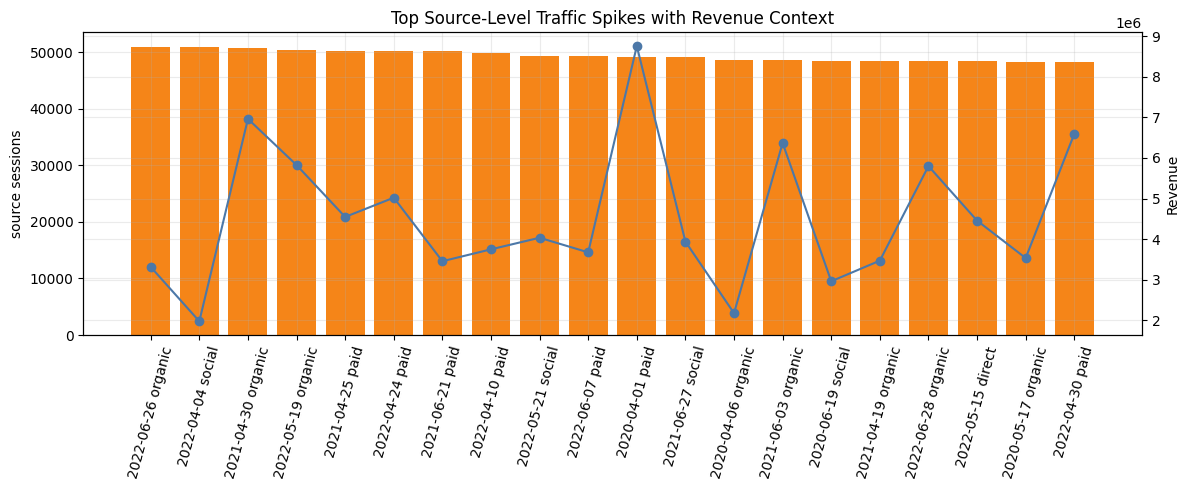

In [12]:
source_spikes = pd.DataFrame()
if traffic_source_daily.empty or 'sessions' not in traffic_source_daily.columns:
    print('Source-level sessions are unavailable; spike checks cannot be computed.')
else:
    spike_rows = []
    for source, g in traffic_source_daily.groupby('traffic_source'):
        s = g['sessions'].astype(float)
        if len(s) < 10 or s.std(ddof=0) == 0:
            continue
        z = (s - s.mean()) / s.std(ddof=0)
        p95 = s.quantile(0.95)
        p99 = s.quantile(0.99)
        flagged = g[(z >= 3) | (s >= p95)].copy()
        flagged['source_session_z_score'] = z.loc[flagged.index]
        flagged['source_session_percentile'] = s.rank(pct=True).loc[flagged.index]
        flagged['source_p95_sessions'] = p95
        flagged['source_p99_sessions'] = p99
        spike_rows.append(flagged)
    source_spikes = pd.concat(spike_rows, ignore_index=True) if spike_rows else pd.DataFrame()
    if source_spikes.empty:
        print('No source-level traffic spikes detected by configured rules.')
    else:
        if not sales_daily.empty:
            rev = sales_daily.copy()
            r = rev['revenue'].astype(float)
            rev_threshold = max(r.quantile(0.95), r.mean() + 3 * r.std(ddof=0))
            rev['revenue_spike'] = rev['revenue'] >= rev_threshold
            source_spikes = source_spikes.merge(rev[['date', 'revenue', 'revenue_spike']], on='date', how='left')
        display(source_spikes.sort_values(['source_session_percentile', 'sessions'], ascending=False)[['date', 'traffic_source', 'sessions', 'revenue', 'revenue_spike', 'source_session_z_score', 'source_session_percentile']].head(50))

        top_plot = source_spikes.sort_values('sessions', ascending=False).head(20)
        fig, ax1 = plt.subplots(figsize=(12, 5))
        labels = top_plot['date'].dt.strftime('%Y-%m-%d') + ' ' + top_plot['traffic_source'].astype(str)
        ax1.bar(labels, top_plot['sessions'], color='#F58518', label='source sessions')
        ax1.set_ylabel('source sessions')
        ax1.tick_params(axis='x', rotation=75)
        if 'revenue' in top_plot.columns:
            ax2 = ax1.twinx()
            ax2.plot(labels, top_plot['revenue'], color='#4C78A8', marker='o', label='Revenue')
            ax2.set_ylabel('Revenue')
        ax1.set_title('Top Source-Level Traffic Spikes with Revenue Context')
        plt.tight_layout()
        plt.show()

## 13. Leakage-Safe Traffic-Source Forecast Feature Preview

Build daily source-level feature candidates. Lagged and rolling features are shifted before rolling, so date `t` does not use source traffic from date `t`. Same-day source-level traffic requires that future/same-day traffic is known before prediction.

In [13]:
feature_preview = pd.DataFrame()
feature_registry = pd.DataFrame()
if joined.empty:
    print('Joined source traffic and Revenue data is unavailable; forecast feature preview cannot be built.')
else:
    feature_preview = joined.sort_values('date').copy()
    source_session_cols = [c for c in feature_preview.columns if c.startswith('sessions_')]
    if 'total_sessions' not in feature_preview.columns and source_session_cols:
        feature_preview['total_sessions'] = feature_preview[source_session_cols].sum(axis=1)
    for c in source_session_cols:
        share_col = c.replace('sessions_', 'share_')
        feature_preview[share_col] = feature_preview[c] / feature_preview['total_sessions'].replace(0, np.nan)
        feature_preview[f'{share_col}_lag_1'] = feature_preview[share_col].shift(1)
        feature_preview[f'{c}_lag_1'] = feature_preview[c].shift(1)
        feature_preview[f'{c}_lag_7'] = feature_preview[c].shift(7)
        feature_preview[f'{c}_roll_mean_7'] = feature_preview[c].shift(1).rolling(7, min_periods=3).mean()

    share_cols = [c for c in feature_preview.columns if c.startswith('share_') and not c.endswith('_lag_1')]
    if share_cols:
        feature_preview['top_source_share'] = feature_preview[share_cols].max(axis=1)
        feature_preview['top_source_share_lag_1'] = feature_preview['top_source_share'].shift(1)
        feature_preview['top_source_share_roll_mean_7'] = feature_preview['top_source_share'].shift(1).rolling(7, min_periods=3).mean()
        feature_preview['source_mix_concentration'] = (feature_preview[share_cols] ** 2).sum(axis=1)
        feature_preview['source_mix_concentration_lag_1'] = feature_preview['source_mix_concentration'].shift(1)

    canonical_sources = ['organic', 'paid', 'email', 'social', 'direct', 'referral']
    preview_cols = ['date']
    for c in ['revenue', 'total_sessions']:
        if c in feature_preview.columns:
            preview_cols.append(c)
    for source in canonical_sources:
        base_col = source_col_map.get(source)
        if base_col:
            for c in [f'{base_col}_lag_1', f'{base_col}_lag_7', f'{base_col}_roll_mean_7', f'share_{safe_col_label(source)}_lag_1']:
                if c in feature_preview.columns:
                    preview_cols.append(c)
    for c in ['top_source_share_lag_1', 'top_source_share_roll_mean_7', 'source_mix_concentration_lag_1']:
        if c in feature_preview.columns:
            preview_cols.append(c)
    display(feature_preview[preview_cols].head(40))

    known_future = source_session_cols + share_cols
    historical_safe = [c for c in feature_preview.columns if c.endswith('_lag_1') or c.endswith('_lag_7') or c.endswith('_roll_mean_7') or c in ['top_source_share_roll_mean_7', 'source_mix_concentration_lag_1']]
    feature_registry = pd.DataFrame({
        'feature': known_future + historical_safe,
        'feature_type': ['requires known future/same-day source traffic'] * len(known_future) + ['historical lag/rolling only'] * len(historical_safe),
        'forecast_use_note': ['Use only if this source-level traffic value is genuinely known before prediction for the forecast/test date.'] * len(known_future) + ['Leakage-safe candidate because it uses shifted history.'] * len(historical_safe),
    }).drop_duplicates()
    display(feature_registry)

,date,revenue,total_sessions,sessions_organic_lag_1,sessions_organic_lag_7,sessions_organic_roll_mean_7,share_organic_lag_1,sessions_paid_lag_1,sessions_paid_lag_7,sessions_paid_roll_mean_7,share_paid_lag_1,sessions_email_lag_1,sessions_email_lag_7,sessions_email_roll_mean_7,share_email_lag_1,sessions_social_lag_1,sessions_social_lag_7,sessions_social_roll_mean_7,share_social_lag_1,sessions_direct_lag_1,sessions_direct_lag_7,sessions_direct_roll_mean_7,share_direct_lag_1,sessions_referral_lag_1,sessions_referral_lag_7,sessions_referral_roll_mean_7,share_referral_lag_1,top_source_share_lag_1,top_source_share_roll_mean_7,source_mix_concentration_lag_1
0,2012-07-04,"5,123,547.9400",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,"2,751,773.4500",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000
2,2012-07-06,"3,054,029.4200",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000
3,2012-07-07,"2,667,930.9400",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000
4,2012-07-08,"2,360,851.9000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000
5,2012-07-09,"3,548,386.4600",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000
6,2012-07-10,"5,234,938.6200",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000
7,2012-07-11,"5,582,884.7800",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000
8,2012-07-12,"5,734,632.0200",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000
9,2012-07-13,"5,309,511.7100",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000


,feature,feature_type,forecast_use_note
0,sessions_direct,requires known future/same-day source traffic,Use only if this source-level traffic value is...
1,sessions_email,requires known future/same-day source traffic,Use only if this source-level traffic value is...
2,sessions_organic,requires known future/same-day source traffic,Use only if this source-level traffic value is...
3,sessions_paid,requires known future/same-day source traffic,Use only if this source-level traffic value is...
4,sessions_referral,requires known future/same-day source traffic,Use only if this source-level traffic value is...
5,sessions_social,requires known future/same-day source traffic,Use only if this source-level traffic value is...
6,share_direct,requires known future/same-day source traffic,Use only if this source-level traffic value is...
7,share_email,requires known future/same-day source traffic,Use only if this source-level traffic value is...
8,share_organic,requires known future/same-day source traffic,Use only if this source-level traffic value is...
9,share_paid,requires known future/same-day source traffic,Use only if this source-level traffic value is...


## 14. Key Observations and Warnings

Final concise summary with traffic share, quality, Revenue correlation, source spike observations, recommended features, and leakage cautions.

In [14]:
def fmt(x, digits=4):
    return 'n/a' if pd.isna(x) else f'{x:,.{digits}f}'

summary_lines = []

if not source_volume.empty:
    top_share = source_volume.head(5)
    summary_lines.append('Largest session-share sources: ' + ', '.join(f"{r.traffic_source} ({r.sessions_share:.1%})" for r in top_share.itertuples()))
else:
    summary_lines.append('Traffic source share could not be summarized because source/session data was unavailable.')

if not source_quality.empty and 'average_bounce_rate' in source_quality.columns:
    low_bounce = source_quality.sort_values('average_bounce_rate').head(5)
    summary_lines.append('Lowest bounce-rate sources: ' + ', '.join(f"{r.traffic_source} ({r.average_bounce_rate:.2%})" for r in low_bounce.itertuples()))
else:
    summary_lines.append('Bounce rate was unavailable or too sparse for source-quality ranking.')

if not source_quality.empty and 'average_session_duration' in source_quality.columns:
    high_duration = source_quality.sort_values('average_session_duration', ascending=False).head(5)
    summary_lines.append('Highest average session-duration sources: ' + ', '.join(f"{r.traffic_source} ({r.average_session_duration:,.1f})" for r in high_duration.itertuples()))
else:
    summary_lines.append('Session duration was unavailable or too sparse for source-quality ranking.')

if not source_correlation.empty:
    best_same_day = source_correlation[source_correlation['feature_type'].eq('same_day')].sort_values('correlation_with_revenue', ascending=False).head(5)
    best_lagged = source_correlation[source_correlation['feature_type'].ne('same_day')].sort_values('correlation_with_revenue', ascending=False).head(5)
    summary_lines.append('Traffic sources most correlated with same-day Revenue: ' + ', '.join(f"{r.traffic_source} ({r.correlation_with_revenue:.4f})" for r in best_same_day.itertuples()))
    summary_lines.append('Strongest lagged/rolling source-Revenue relationships: ' + ', '.join(f"{r.feature} ({r.correlation_with_revenue:.4f})" for r in best_lagged.itertuples()))
    canonical = ['organic', 'paid', 'email', 'social']
    canonical_rows = source_correlation[(source_correlation['traffic_source'].isin(canonical)) & (source_correlation['feature_type'].eq('same_day'))]
    if not canonical_rows.empty:
        summary_lines.append('Organic/paid/email/social same-day Revenue correlations: ' + ', '.join(f"{r.traffic_source}={r.correlation_with_revenue:.4f}" for r in canonical_rows.sort_values('traffic_source').itertuples()))
else:
    summary_lines.append('Source-level Revenue correlations could not be computed because joined source traffic and Revenue were unavailable.')

if not source_spikes.empty:
    spike_count = len(source_spikes)
    overlap_count = int(source_spikes['revenue_spike'].fillna(False).sum()) if 'revenue_spike' in source_spikes.columns else 0
    top_spikes = source_spikes.sort_values('sessions', ascending=False).head(5)
    summary_lines.append(f'Source-level session spikes detected: {spike_count}; with same-day Revenue spike flag: {overlap_count}.')
    summary_lines.append('Largest source-level spike observations: ' + ', '.join(f"{pd.Timestamp(r.date).date()} {r.traffic_source} ({r.sessions:,.0f})" for r in top_spikes.itertuples()))
else:
    summary_lines.append('No source-level traffic spikes were detected by the configured rules, or source sessions were unavailable.')

if not source_trends.empty:
    selected = source_trends[source_trends['traffic_source'].isin(['organic', 'paid', 'email', 'social', 'direct', 'referral'])]
    if not selected.empty:
        summary_lines.append('Major source trend directions: ' + ', '.join(f"{r.traffic_source}={r.trend_direction}" for r in selected.sort_values('traffic_source').itertuples()))

if traffic_warnings:
    summary_lines.append('Traffic warnings: ' + '; '.join(traffic_warnings))
if sales_warnings:
    summary_lines.append('Sales warnings: ' + '; '.join(sales_warnings))

summary_lines.append('Recommended traffic-source forecast features: traffic_source_share_lag, organic_sessions_lag_1/7, paid_sessions_lag_1/7, email_sessions_lag_1/7, social_sessions_lag_1/7, source_sessions_roll_mean_7 for major sources, top_source_share_lag_1, top_source_share_roll_mean_7, and source_mix_concentration_lag_1.')
summary_lines.append('Leakage warning: true future traffic-source values must not be used directly unless known before prediction. Otherwise forecast traffic by source first or use only historical lagged/pattern features.')
summary_lines.append('Causal caution: this is observational EDA. Source quality and Revenue can move together because of campaign timing, seasonality, targeting, promotions, product mix, and stock availability.')

print('KEY OBSERVATIONS AND WARNINGS')
for line in summary_lines:
    print('-', line)

KEY OBSERVATIONS AND WARNINGS
- Largest session-share sources: organic (29.7%), paid (21.4%), social (17.3%), email (14.0%), referral (10.4%)
- Lowest bounce-rate sources: email (0.44%), social (0.45%), paid (0.45%), organic (0.45%), direct (0.45%)
- Highest average session-duration sources: email (212.5), organic (211.1), social (211.0), paid (208.3), direct (206.1)
- Traffic sources most correlated with same-day Revenue: social (0.0806), paid (0.0686), organic (0.0451), email (0.0418), referral (0.0357)
- Strongest lagged/rolling source-Revenue relationships: sessions_social_roll_mean_7 (0.1586), sessions_paid_roll_mean_7 (0.1527), sessions_organic_roll_mean_7 (0.1310), sessions_referral_roll_mean_7 (0.1078), sessions_email_roll_mean_7 (0.1019)
- Organic/paid/email/social same-day Revenue correlations: email=0.0418, organic=0.0451, paid=0.0686, social=0.0806
- Source-level session spikes detected: 186; with same-day Revenue spike flag: 1.
- Largest source-level spike observations: 20